In [2]:
#Module4-1-3 

# Train a LinearRegression model using X_train and y_train.
# Score your model using X_test and y_test.

from sklearn.datasets import load_boston
X, y = load_boston(return_X_y=True)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)
from sklearn.linear_model import LinearRegression
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)  
score=regression_model.score(X_test, y_test)
print(f'Model R^2 score: {score}')


ImportError: 
`load_boston` has been removed from scikit-learn since version 1.2.

The Boston housing prices dataset has an ethical problem: as
investigated in [1], the authors of this dataset engineered a
non-invertible variable "B" assuming that racial self-segregation had a
positive impact on house prices [2]. Furthermore the goal of the
research that led to the creation of this dataset was to study the
impact of air quality but it did not give adequate demonstration of the
validity of this assumption.

The scikit-learn maintainers therefore strongly discourage the use of
this dataset unless the purpose of the code is to study and educate
about ethical issues in data science and machine learning.

In this special case, you can fetch the dataset from the original
source::

    import pandas as pd
    import numpy as np

    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[:

In [3]:
#Module4-1-3 
# Your code should perform the following tasks to complete this mission:

# Train a LinearRegression model using sepal_train and petal_length_train.
# Score your model using sepal_test and petal_length_test.
from sklearn.datasets import load_iris
X, _ = load_iris(return_X_y=True)

sepal = X[:, :2]
petal_length = X[:, 2]

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
sepal_train, sepal_test, petal_length_train, petal_length_test = train_test_split(sepal, petal_length, test_size=0.33, random_state=0)
regression_model = LinearRegression()
regression_model.fit(sepal_train, petal_length_train)
score=regression_model.score(sepal_test, petal_length_test)

print(f'Model R^2 score: {score}')


Model R^2 score: 0.8486246655918517


## Load Boston dataset from boston.txt

This cell parses the whitespace-separated numbers in `boston.txt` (some rows are split across lines) and creates a DataFrame `df_boston` with the correct column names.


In [19]:
# Load Boston dataset from `boston.txt` into a DataFrame
# This handles rows split across lines and builds a DataFrame with proper column names
#  Variables in order:
#  CRIM     per capita crime rate by town
#  ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
#  INDUS    proportion of non-retail business acres per town
#  CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
#  NOX      nitric oxides concentration (parts per 10 million)
#  RM       average number of rooms per dwelling
#  AGE      proportion of owner-occupied units built prior to 1940
#  DIS      weighted distances to five Boston employment centres
#  RAD      index of accessibility to radial highways
#  TAX      full-value property-tax rate per $10,000
#  PTRATIO  pupil-teacher ratio by town
#  B        1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
#  LSTAT    % lower status of the population
#  MEDV     Median value of owner-occupied homes in $1000's

import re
from pathlib import Path
import pandas as pd

file_path = Path('boston.txt')
if not file_path.exists():
    raise FileNotFoundError(f"{file_path} not found. Place 'boston.txt' in the notebook directory.")

pattern = r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?'
rows = []
current = []
with file_path.open('r') as f:
    # Skip the first 22 lines (header/description)
    for _ in range(22):
        next(f, None)

    for line in f:
        nums = re.findall(pattern, line)
        if nums:
            current.extend(map(float, nums))
            while len(current) >= 14:
                rows.append(current[:14])
                current = current[14:]

if current:
    print('Warning: leftover numeric tokens (incomplete row):', current)

columns = ['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE','DIS','RAD','TAX','PTRATIO','B','LSTAT','MEDV']
df_boston = pd.DataFrame(rows, columns=columns)

print('Loaded rows:', df_boston.shape[0])
df_boston.head()

Loaded rows: 506


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [45]:
# Save the DataFrame to a CSV file
df_boston.to_csv('boston.csv', index=False)

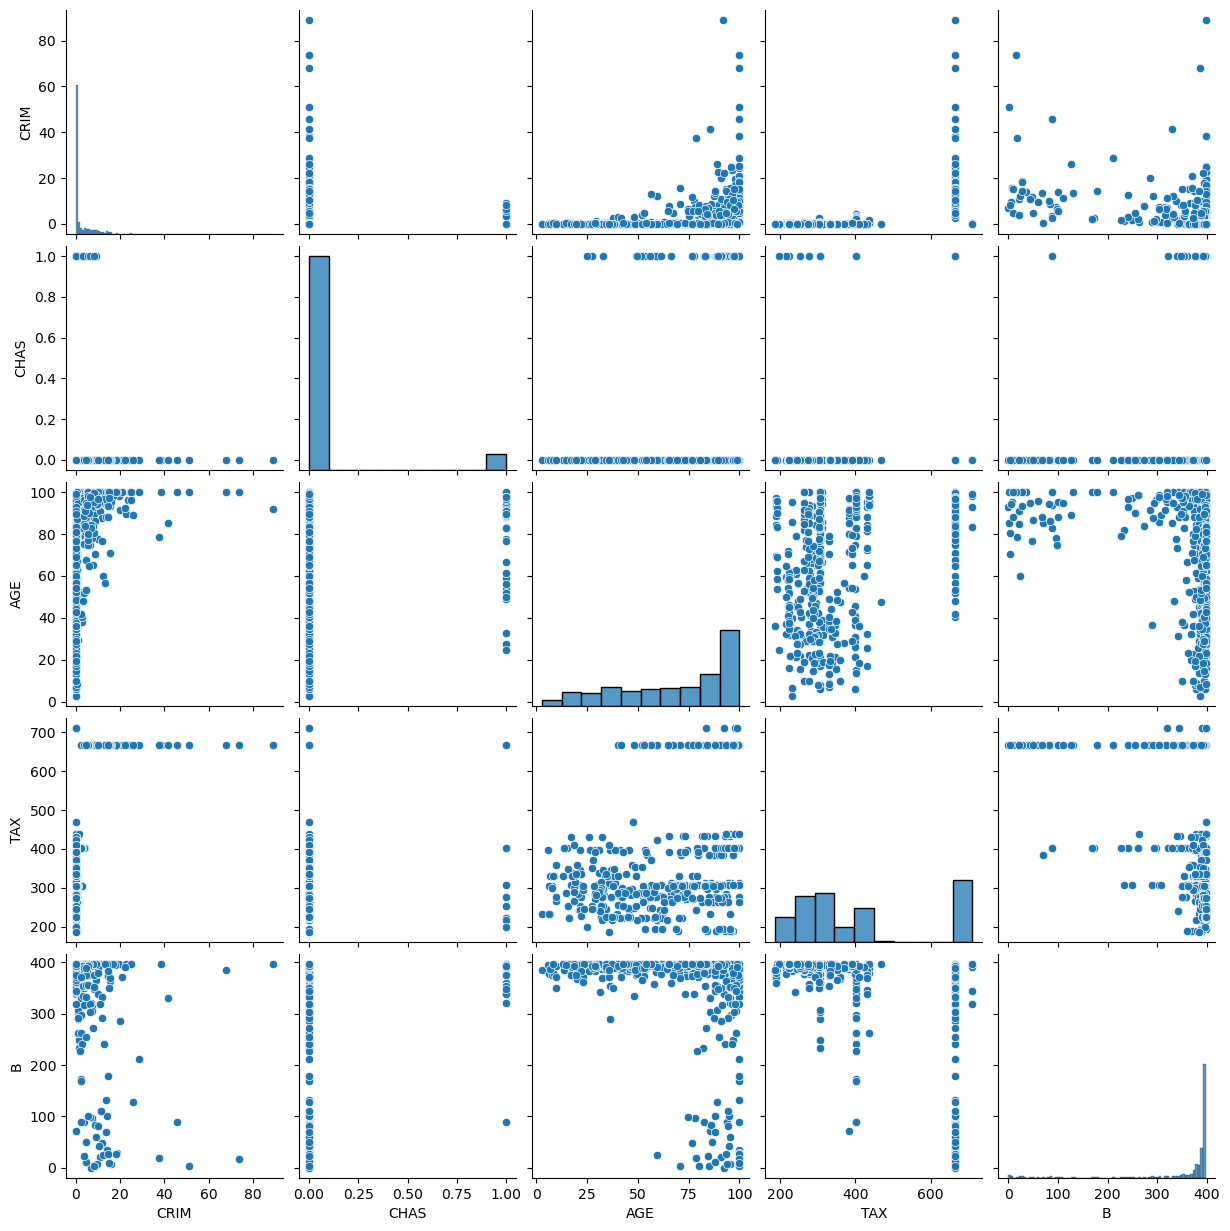

In [33]:
# Module 4.1-4 Editor Boston house price
# Let us retry regression with the Boston House prices dataset using Linear Regression!
# Your code should perform the following tasks to complete this mission:
# 1.  Train a LinearRegression model using X_train and y_train
# 2.  Score your model using X_test and y_test.
import numpy as np
import seaborn as sns

X = df_boston.drop(columns=['MEDV'])
y= df_boston['MEDV']
X.columns
sns.pairplot(X, vars = ['CRIM', 'CHAS', 'AGE', 'TAX','B'] )


<Axes: >

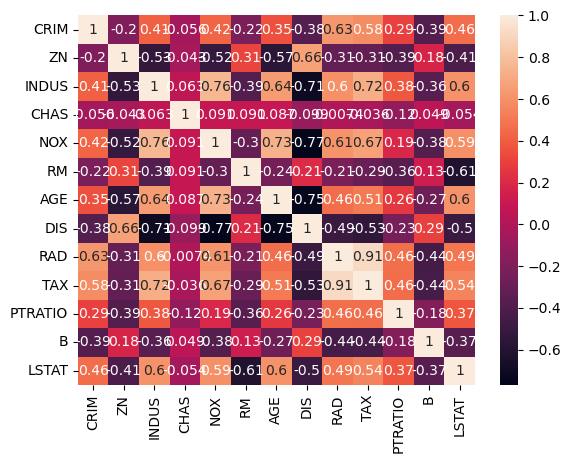

In [22]:
sns.heatmap(X.corr(), annot=True) 

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
# X_scale=StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)
from sklearn.linear_model import LinearRegression
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)  
score=regression_model.score(X_test, y_test)    
print(f'Model R^2 score: {score}')

Model R^2 score: 0.6705795412578816


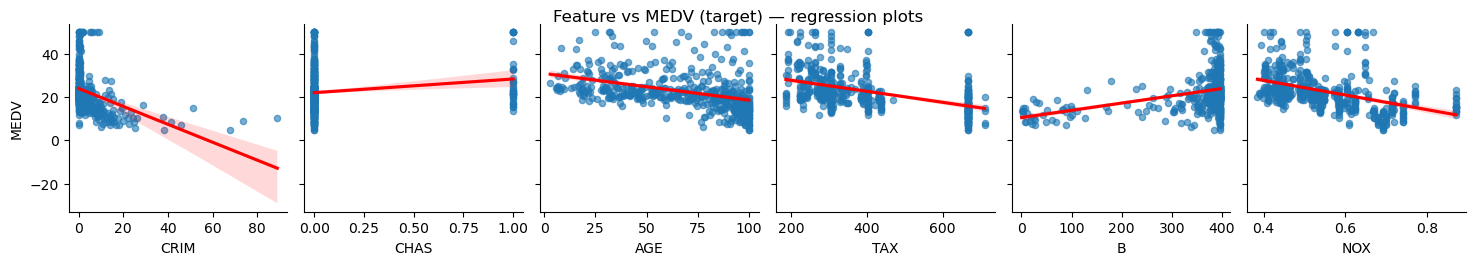

In [44]:
# Pair plots: each feature vs target (MEDV)
import matplotlib.pyplot as plt
# Create a grid of scatter + regression plots of each feature against MEDV
sns.pairplot(df_boston, x_vars = ['CRIM', 'CHAS', 'AGE', 'TAX','B',
                                  'NOX'],y_vars=['MEDV'],kind='reg', plot_kws={'scatter_kws': {'s': 20, 'alpha': 0.6}, 'line_kws': {'color': 'red'}})
plt.suptitle('Feature vs MEDV (target) — regression plots', y=1.02)
plt.show()

In [43]:
# Feature importance for continuous target (MEDV)
from sklearn.feature_selection import mutual_info_regression, SelectKBest, f_regression

# Choose k (top features to keep)
k = min(10, X.shape[1])

# Mutual information (non-parametric)
selector_mi = SelectKBest(mutual_info_regression, k=k)
selector_mi.fit(X, y)
mi_scores = selector_mi.scores_
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# F-test (linear correlation)
selector_f = SelectKBest(f_regression, k=k)
selector_f.fit(X, y)
f_scores = selector_f.scores_
f_series = pd.Series(f_scores, index=X.columns).sort_values(ascending=False)

print("Top features by mutual information score:")
print(mi_series.head(k))
print("\nTop features by f_regression score:")
print(f_series.head(k))

# Pick top-k features (choose method: mutual info here)
selected_method = 'mutual_info'  # or 'f_regression'
if selected_method == 'mutual_info':
    top_features = mi_series.head(k).index.tolist()
else:
    top_features = f_series.head(k).index.tolist()

print(f"\nSelected top-{k} features ({selected_method}): {top_features}")

# Reduced dataframe containing only selected features
df_reduced = X[top_features].copy()
df_reduced.head()

# Train a LinearRegression model using reduced feature set
regression_model_reduced = LinearRegression()
X_train_reduced, X_test_reduced, y_train, y_test = train_test_split(df_reduced, y, test_size=0.33, random_state=0)
regression_model_reduced.fit(X_train_reduced, y_train)  
score_reduced=regression_model_reduced.score(X_test_reduced, y_test)    
print(f'Best Features Selector method: {selected_method}')
print(f'Reduced model R^2 score: {score_reduced}')
score=score_reduced

# Use coefficients from fitted LinearRegression
coefs = regression_model_reduced.coef_
feat_imp = pd.DataFrame({'coefficient': coefs}, index=X_train_reduced.columns)
feat_imp['abs_coef'] = feat_imp['coefficient'].abs()
feat_imp = feat_imp.sort_values('abs_coef', ascending=False)
print("\nFeature importances based on coefficients:")
print("feature imparance:",feat_imp)

Top features by mutual information score:
LSTAT      0.667530
RM         0.527917
INDUS      0.470295
NOX        0.462334
PTRATIO    0.443357
TAX        0.360729
CRIM       0.335283
AGE        0.308779
DIS        0.297706
RAD        0.225724
dtype: float64

Top features by f_regression score:
LSTAT      601.617871
RM         471.846740
PTRATIO    175.105543
INDUS      153.954883
TAX        141.761357
NOX        112.591480
CRIM        89.486115
RAD         85.914278
AGE         83.477459
ZN          75.257642
dtype: float64

Selected top-10 features (mutual_info): ['LSTAT', 'RM', 'INDUS', 'NOX', 'PTRATIO', 'TAX', 'CRIM', 'AGE', 'DIS', 'RAD']
Best Features Selector method: mutual_info
Reduced model R^2 score: 0.6452905725577884

Feature importances based on coefficients:
feature imparance:          coefficient   abs_coef
NOX       -18.347076  18.347076
RM          3.892657   3.892657
DIS        -1.326814   1.326814
PTRATIO    -1.209052   1.209052
LSTAT      -0.537711   0.537711
RAD      

In [ ]:
#Module4-1-4 Editor Iris 

# Your code should perform the following tasks to complete this mission:

# Train a LinearRegression model using sepal_train and petal_width_train.
# Score your model using sepal_test and petal_width_test.

from sklearn.datasets import load_iris
X, _ = load_iris(return_X_y=True)
sepal = X[:, :2]
petal_length = X[:, 3]
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression   
sepal_train, sepal_test, petal_length_train, petal_length_test = train_test_split(sepal, petal_length, test_size=0.33, random_state=0)
regression_model = LinearRegression()
regression_model.fit(sepal_train, petal_length_train)
score=regression_model.score(sepal_test, petal_length_test)
print(f'Model R^2 score: {score}')



    

In [47]:
# Module 4-1-5 KNeighborsRegressor Boston house price
# Let's try regression with the Iris dataset using KNN!
# To complete this mission, your code should perform the following tasks:
# 1.  Train a KNeighborsRegressor model using X_train and y_train with the following parameters:
# 5 neighbours
# 2.  Score your model using sepal_test and petal_length_test.

from sklearn.datasets import load_iris
X, _ = load_iris(return_X_y=True)
sepal = X[:, :2]
petal_length = X[:, 2]

from sklearn.model_selection import train_test_split
sepal_train, sepal_test, petal_length_train, petal_length_test = train_test_split(sepal, petal_length, test_size=0.33, random_state=0)

from sklearn.neighbors import KNeighborsRegressor

regression_model = KNeighborsRegressor(n_neighbors=5)
regression_model.fit(sepal_train, petal_length_train)
#score=regression_model.score(sepal_test, petal_length_test)
score=regression_model.score(sepal_test, petal_length_test)
print(f'Model R^2 score: {score}')



Model R^2 score: 0.9304881803763456


In [ ]:
# Module 4-1-6 KNeighborsRegressor Boston house price
# To complete this m